In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
# 1. Baca train dan test dari file NPZ.
with np.load("data/mnist.npz", allow_pickle=False) as data:
    print("Array dalam NPZ:", data.files)

    x_train_original = data["x_train"]
    y_train_original = data["y_train"]
    x_test = data["x_test"]
    y_test = data["y_test"]

# Periksa ukuran dataset MNIST standar.
if x_train_original.shape != (60000, 28, 28):
    raise ValueError("Training harus berukuran (60000, 28, 28).")

if x_test.shape != (10000, 28, 28):
    raise ValueError("Test harus berukuran (10000, 28, 28).")

Array dalam NPZ: ['x_test', 'x_train', 'y_train', 'y_test']


In [5]:
# 2. Normalisasi piksel dari 0–255 menjadi 0–1.
x_train_original = x_train_original.astype(np.float32) / 255.0
x_test = x_test.astype(np.float32) / 255.0

# Tambahkan satu kanal karena gambar grayscale.
# Bentuk berubah dari (N, 28, 28) menjadi (N, 28, 28, 1).
x_train_original = x_train_original[..., np.newaxis]
x_test = x_test[..., np.newaxis]

In [6]:
# 3. Acak indeks training saja.
# Seed tetap menghasilkan pembagian yang sama saat dijalankan ulang.
rng = np.random.default_rng(seed=42)
indices = rng.permutation(len(x_train_original))

n_train = int(0.9 * len(indices))
train_indices = indices[:n_train]
val_indices = indices[n_train:]

# Gambar dan label menggunakan indeks yang sama.
x_train = x_train_original[train_indices]
y_train = y_train_original[train_indices]

x_val = x_train_original[val_indices]
y_val = y_train_original[val_indices]

# Test tetap berasal dari pembagian resmi, tanpa diacak atau dicampur.

In [7]:
# 4. Tampilkan jumlah, bentuk, tipe data, dan rentang piksel.
for nama, gambar in [
    ("Latihan", x_train),
    ("Validasi", x_val),
    ("Test", x_test),
]:
    print(
        f"{nama}: {len(gambar):,} gambar | "
        f"bentuk={gambar.shape} | dtype={gambar.dtype} | "
        f"piksel=[{gambar.min():.1f}, {gambar.max():.1f}]"
    )

Latihan: 54,000 gambar | bentuk=(54000, 28, 28, 1) | dtype=float32 | piksel=[0.0, 1.0]
Validasi: 6,000 gambar | bentuk=(6000, 28, 28, 1) | dtype=float32 | piksel=[0.0, 1.0]
Test: 10,000 gambar | bentuk=(10000, 28, 28, 1) | dtype=float32 | piksel=[0.0, 1.0]


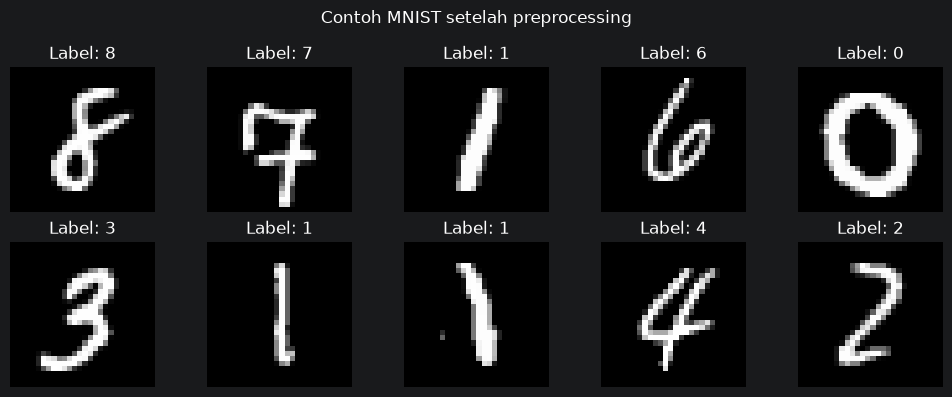

In [8]:
# 5. Tampilkan 10 contoh gambar latihan setelah preprocessing.
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i, :, :, 0], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis("off")

fig.suptitle("Contoh MNIST setelah preprocessing")
plt.tight_layout()
plt.show()